---
title: "CNN Multi-class classification Pytorch"
author: "Jorge Bris Moreno"
format:
  html:
    embed-resources: true
---

## Lab-3.1: CNN Multi-class classification 

In this lab we perform multi-class classification with a CNN using `PyTorch` **AND** `Keras`. 

**Submission:**

* You need to upload TWO documents to Canvas when you are done
  * (1) A PDF (or HTML) of the completed form of the completed `MNIST.ipynb` notebook (MNIST in Keras)
  * (1) A PDF (or HTML) of the completed form of the completed `CIFAR.ipynb` notebook (CIFAR in PyTorch)
* The final uploaded version should NOT have any code-errors present 
* All outputs must be visible in the uploaded version, including code-cell outputs, images, graphs, etc

**Instructions** 

* Code Multi-class classification using LeNet type architecture CNN to train
  * (1) MNIST training with Keras, in `MNIST.ipynb`.
  * (2) CIFAR training with PyTorch, in `CIFAR.ipynb`.
  * **If you use an online reference, please cite the source and don't copy more than a few lines of code**
  * Normalize the data as needed
  * Visualize the results at the end where possible
  * Partition data into training, validation, and test
  * Monitor training and validation throughout training by plotting
  * For the final fit, report the confusion matrix at the end
  * Print training, validation, and test errors at the very end
  * You `MUST` use early stopping: 
  * Do basic `MANUAL` hyper-parameter tuning to try to achieve an optimal fit model
    * i.e. best training/validation loss without over-fitting
    * Explore L1 and L2 regularization and dropout
    * Explore different optimizers 
    * Use the loss functions specified in the textbook
    * Explore different options for activation functions, network size/depth, etc
* **Document what is going on in the code, as needed, with narrative markdown text between cells.**
* *Submit the version with hyper parameters that provide the optimal fit*
  * i.e. you don't need to show the outputs of your hyper-parameter tuning process

# Architecture:
We will use LeNET 5 architecture for CIFAR10 dataset to have the same architecture as the Keras model. That way, it would be easier to compare the results for the different datasets. Furthermore, the hyperparameters have been tuned as described and my optimal ones are the ones in this version.

In [2]:
# Libraries
import torch
from torch import nn
from torchvision import datasets
from torchvision.transforms import Compose, Normalize, ToTensor
from torch.utils.data import DataLoader, random_split
from sklearn.model_selection import KFold
import numpy as np
import copy
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.init as init
from sklearn.model_selection import KFold
import copy
import pandas as pd
import seaborn as sns
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data.sampler import SubsetRandomSampler
from sklearn.metrics import confusion_matrix 


This cell downloads the CIFAR10 dataset and normalizes it. It also makes it a tensor and uses the dsts loader to load the data. The training data was split into training and validation, and then we had a test set as usual to obtain our accruacy and test the model. The batch size was set to 64 as it gave better results and would take less time to train.

In [3]:
# Transform the data into tensor and normalize it
transform = Compose([ToTensor(), Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])

# Load the data with the transformation
training_data = datasets.CIFAR10(root="data", train=True, download=True, transform=transform)
test_data = datasets.CIFAR10(root="data", train=False, download=True, transform=transform)

# Training and validation split
train_size = int(0.8 * len(training_data))
val_size = len(training_data) - train_size
train_dataset, val_dataset = random_split(training_data, [train_size, val_size])

# Batch size
batch_size = 64

# data loaders
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

Files already downloaded and verified
Files already downloaded and verified


Now, we get some information about the data.

In [4]:
# explore data-set object
print("\n TYPE:\n",type(training_data))
print("\n SUMMARY:\n",training_data)
print("\n ATTRIBUTES:\n",training_data.__dict__.keys())
print("\n FIRST DATA POINT:\n",)
img, label = training_data[0]
print(img.shape,label)
print(len(training_data))


 TYPE:
 <class 'torchvision.datasets.cifar.CIFAR10'>

 SUMMARY:
 Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )

 ATTRIBUTES:
 dict_keys(['root', 'transform', 'target_transform', 'transforms', 'train', 'data', 'targets', 'classes', 'class_to_idx'])

 FIRST DATA POINT:

torch.Size([3, 32, 32]) 6
50000


In [5]:
# from demonstart data loader
# for X, y in test_dataloader:
for X, y in train_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 3, 32, 32])
Shape of y: torch.Size([64]) torch.int64


We define the class LeNet5, which is the architecture we will use for the CNN. It has 2 convolutional layers. The activation function is ReLU and the pooling is max pooling. The forward function is defined to pass the data through the layers and get the output. The architecture was obtained from James code in the website and the class was defined to deal with gray images as well as color (since it was not too hard) in case I need to refer to it in the future.

In [6]:
# LeNet5 model (architecture from James sample code in website)

# LeNet 5
class LeNet5(nn.Module):
    # init method
    def __init__(self, num_classes=10, grayscale=False, dropout=0):
        # super class
        super(LeNet5, self).__init__()
        # grayscale or not
        self.grayscale = grayscale
        self.num_classes = num_classes

        # channels if grayscale or not
        if self.grayscale:
            in_channels = 1
        else:
            in_channels = 3

        # 1st layer (convolutional layer)
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 6, kernel_size=5, stride=1),
            nn.BatchNorm2d(6),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # 2nd layer (convolutional layer)
        self.layer2 = nn.Sequential(
            nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2)
        )

        # fully connected layer after flattening
        self.fc_size = 16 * 5 * 5

        # first fully connected layer
        self.fc = nn.Sequential(nn.Linear(self.fc_size, 120), nn.ReLU(), nn.Dropout(dropout),)

        # second fully connected layer
        self.fc1 = nn.Sequential(nn.Linear(120, 84), nn.ReLU(), nn.Dropout(dropout),)

        # transform features into classes
        self.fc2 = nn.Linear(84, num_classes)


    # forward pass
    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = F.relu(self.fc(out))
        out = F.relu(self.fc1(out))
        return self.fc2(out)


Now, as usual, we define early stopping. We will use a patience of 5 and we made it a class for the first time as I have researched in many places that it is better and common practice to do it that way.

In [7]:
# First time making Early stopping a class. Resrearched that is a common and better practice to make it a class
class EarlyStopping:
    
    def __init__(self, patience=5, min_delta=0):

        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss == None:
            self.best_loss = val_loss
        elif self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                print('Early stopping!')
                self.early_stop = True


Now, we train the model. We define the function and train it. We have found that having learning rate of 0.001, l1=0, l2=0.001, and droput=0 as the best hyperparameters. We also use the Adam optimizer and the cross entropy loss function. We train the model and then we plot the training and validation loss.

In [8]:
# Using cuda if available (not for mac at the moment)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LeNet5(num_classes=10).to(device)

# L1 value
l1_lambda = 0.0

# optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001) 
CrossEntropyLoss = nn.CrossEntropyLoss()

# EarlyStopping
early_stopping = EarlyStopping(patience=5, min_delta=0)

def train_model(model, CrossEntropyLoss, optimizer, num_epochs=50):

    # saving values
    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []
    
    # training
    for epoch in range(num_epochs):
        # training initialization
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        # training loop over data
        for images, labels in train_dataloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = CrossEntropyLoss(outputs, labels)

            # L1 and total loss
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            total_loss = loss + l1_lambda * l1_norm
            total_loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_losses.append(running_loss / len(train_dataloader.sampler))
        train_accuracies.append(100 * correct / total)
        
        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        # no gradient calculation (not needed during validation)
        with torch.no_grad():
            # validation loop over data
            for images, labels in val_dataloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = CrossEntropyLoss(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_losses.append(val_loss / len(val_dataloader.sampler))
        val_accuracies.append(100 * correct / total)
        
        print(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f}, Training Accuracy: {train_accuracies[-1]:.2f}%, Validation Accuracy: {val_accuracies[-1]:.2f}%')
        
        # Early stopping
        early_stopping(val_losses[-1])
        if early_stopping.early_stop:
            print("Early stopping!")
            break
    
    return train_losses, val_losses, train_accuracies, val_accuracies

# Train model
train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, CrossEntropyLoss, optimizer, num_epochs=50)


Epoch [1/50], Training Loss: 1.5410, Validation Loss: 1.3448, Training Accuracy: 43.13%, Validation Accuracy: 51.45%
Epoch [2/50], Training Loss: 1.2834, Validation Loss: 1.2955, Training Accuracy: 53.72%, Validation Accuracy: 53.08%
Epoch [3/50], Training Loss: 1.1733, Validation Loss: 1.1548, Training Accuracy: 58.05%, Validation Accuracy: 58.81%
Epoch [4/50], Training Loss: 1.1030, Validation Loss: 1.2103, Training Accuracy: 60.67%, Validation Accuracy: 56.84%
Epoch [5/50], Training Loss: 1.0485, Validation Loss: 1.0685, Training Accuracy: 62.52%, Validation Accuracy: 62.51%
Epoch [6/50], Training Loss: 0.9999, Validation Loss: 1.0822, Training Accuracy: 64.51%, Validation Accuracy: 61.93%
Epoch [7/50], Training Loss: 0.9620, Validation Loss: 1.0536, Training Accuracy: 65.61%, Validation Accuracy: 62.69%
Epoch [8/50], Training Loss: 0.9277, Validation Loss: 1.0206, Training Accuracy: 67.11%, Validation Accuracy: 64.05%
Epoch [9/50], Training Loss: 0.8941, Validation Loss: 1.0274, Tr

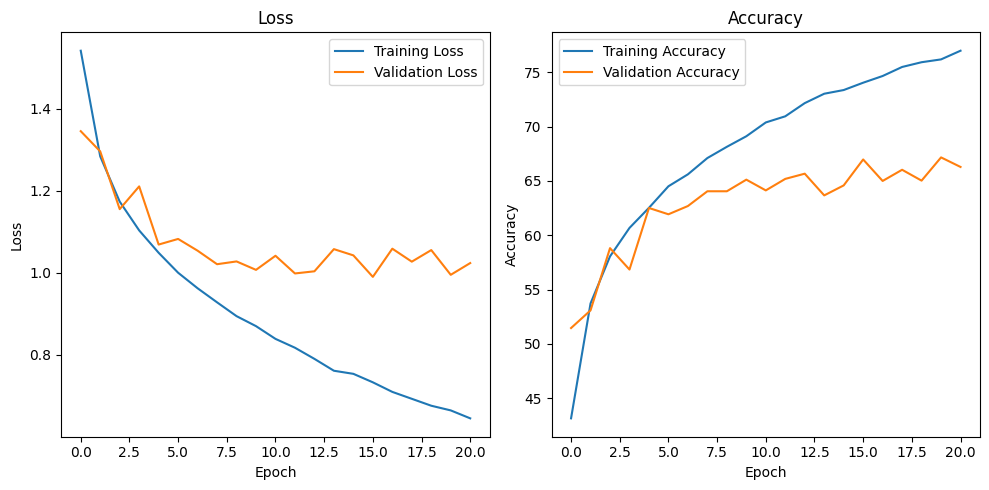

In [9]:
# Plot
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
# Test the model
# In test phase, we don't need to compute gradients (for memory efficiency)

# Test the model
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_dataloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print('Test Accruacy: {} %'.format(100 * correct / total))
     

Test Accruacy: 65.53 %


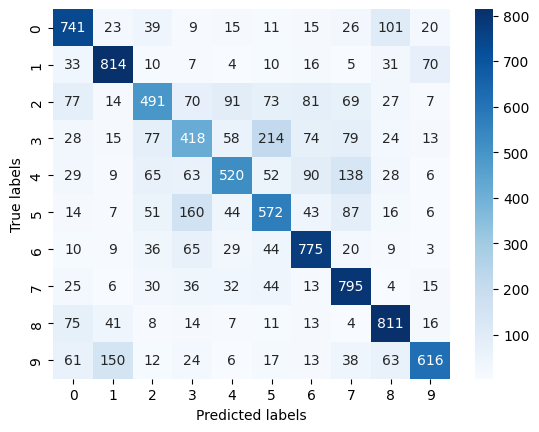

In [11]:
# confusion matrix
y_pred = []
y_true = []
model.eval()

with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_pred.extend(predicted.view(-1).tolist())
        y_true.extend(labels.view(-1).tolist())

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()
